In [13]:
import pandas as pd
import numpy as np
import talib as ta
import matplotlib.pyplot as plt
from datetime import datetime
import os
from binance.client import Client

In [ ]:
api_key = os.environ.get('binance_api')
api_secret = os.environ.get('binance_secret')
client = Client(api_key, api_secret)

# ====  設定起始與結束時間（2025年5月～7月） ====
start_str = '2023-07-26 00:00:00'
end_str = '2025-07-27 23:59:59'
start_ts = int(datetime.strptime(start_str, "%Y-%m-%d %H:%M:%S").timestamp() * 1000)
end_ts = int(datetime.strptime(end_str, "%Y-%m-%d %H:%M:%S").timestamp() * 1000)
bars = client.get_historical_klines('BTCUSDT', '5m', start_ts, end_ts)

with open('15min.csv', 'w', newline='') as f:
    for line in bars:
        del line[6:]
    df = pd.DataFrame(bars, columns=['date', 'Open', 'High', 'Low', 'Close', 'Volume'])
    df['seconds'] = np.floor_divide(df['date'], 1000)
    df['date'] = df['seconds'].apply(lambda x: datetime.fromtimestamp(x).strftime('%Y-%m-%d %H:%M:%S'))
    df.set_index('date', inplace=True)
    print(df.head()) 
    df.to_csv('15min.csv')

                               Open            High             Low  \
date                                                                  
2023-07-26 00:00:00  29181.50000000  29196.28000000  29181.50000000   
2023-07-26 00:05:00  29196.27000000  29225.07000000  29196.27000000   
2023-07-26 00:10:00  29225.07000000  29251.41000000  29225.06000000   
2023-07-26 00:15:00  29249.83000000  29295.76000000  29236.84000000   
2023-07-26 00:20:00  29290.71000000  29290.71000000  29253.91000000   

                              Close        Volume     seconds  
date                                                           
2023-07-26 00:00:00  29196.28000000   66.36870000  1690300800  
2023-07-26 00:05:00  29225.07000000   95.38690000  1690301100  
2023-07-26 00:10:00  29249.84000000  124.22095000  1690301400  
2023-07-26 00:15:00  29290.71000000  158.90763000  1690301700  
2023-07-26 00:20:00  29256.00000000   68.80596000  1690302000  


====== 回測報告 (Vegas + DMI/ADX, 手動回測 | 狀態機版) ======
資料根數: 69,668 | 估計週期: 15.00 分/根
部位變化次數（反手算2）: 202
估計交易筆數（開/平各記一次 -> /2）: 101
總報酬率: 19.88%
CAGR年化: 9.55%
Sharpe  : 0.59
最大回撤: -23.74%
勝率(逐根): 6.46%
單邊費用 : 0.050%


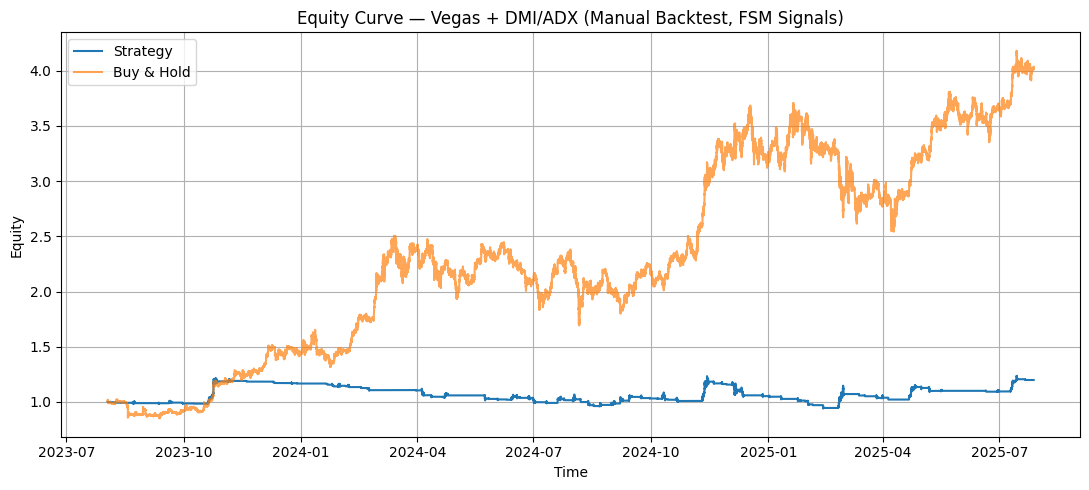

In [ ]:
# ===== 參數 =====
FEE_PER_SIDE = 0.0005        # 單邊手續費/滑價 (0.05%)
STEP_SEC = 15 * 60.0         # 固定 15 分鐘K線
DMI_LEN = 14
ADX_EXIT_TH = 20
WARMUP = 700                  # 暖機裁切，避免EMA初期不穩定
# =================

# ---------- 讀資料 ----------
df = pd.read_csv('15min.csv', index_col=0, parse_dates=True)
df = df[['High', 'Low', 'Open', 'Close', 'Volume']].astype(float).sort_index()

# ---------- 指標（Vegas + DMI/ADX + ATR） ----------
df['ema12']  = ta.EMA(df['Close'], timeperiod=12)
df['ema144'] = ta.EMA(df['Close'], timeperiod=144)
df['ema169'] = ta.EMA(df['Close'], timeperiod=169)
df['ema576'] = ta.EMA(df['Close'], timeperiod=576)
df['ema676'] = ta.EMA(df['Close'], timeperiod=676)

df['plusDI']  = ta.PLUS_DI(df['High'], df['Low'], df['Close'], timeperiod=DMI_LEN)
df['minusDI'] = ta.MINUS_DI(df['High'], df['Low'], df['Close'], timeperiod=DMI_LEN)
df['adx']     = ta.ADX(df['High'], df['Low'], df['Close'], timeperiod=DMI_LEN)
df['atr']     = ta.ATR(df['High'], df['Low'], df['Close'], timeperiod=14)

# Vegas 多空排列
df['vegasLong']  = np.minimum(df['ema144'], df['ema169']) > np.maximum(df['ema576'], df['ema676'])
df['vegasShort'] = np.minimum(df['ema144'], df['ema169']) < np.maximum(df['ema576'], df['ema676'])

# 暖機裁切
df = df.iloc[WARMUP:].copy()

# ---------- 訊號 ----------
def crossover(a: pd.Series, b: pd.Series) -> pd.Series:
    return (a > b) & (a.shift(1) <= b.shift(1))

def crossdown(a: pd.Series, b: pd.Series) -> pd.Series:
    return (a < b) & (a.shift(1) >= b.shift(1))

long_entry = (
    df['vegasLong']
    & crossover(df['Close'], df['ema144'])
    & (df['ema12'] > df['ema144'])
    & (df['plusDI'] > df['minusDI'])
)

short_entry = (
    df['vegasShort']
    & crossdown(df['Close'], df['ema144'])
    & (df['ema12'] < df['ema144'])
    & (df['plusDI'] < df['minusDI'])
)

long_exit  = (df['adx'] < ADX_EXIT_TH) & (df['ema12'] < df['ema144'])
short_exit = (df['adx'] < ADX_EXIT_TH) & (df['ema12'] > df['ema144'])

# ---------- 狀態機產生持倉（與 vectorbt.from_signals 行為對齊） ----------
le = long_entry.fillna(False).to_numpy()
se = short_entry.fillna(False).to_numpy()
lx = long_exit.fillna(False).to_numpy()
sx = short_exit.fillna(False).to_numpy()

pos = np.zeros(len(df), dtype=float)   # 1 / 0 / -1
for i in range(1, len(df)):
    prev = pos[i-1]

    if prev == 0:  # 空手 → 僅能開倉
        if le[i] and not se[i]:
            pos[i] = 1.0
        elif se[i] and not le[i]:
            pos[i] = -1.0
        elif le[i] and se[i]:
            # 同棒同時出現多/空進場時，採「不開倉」處理（可依需求改偏好）
            pos[i] = 0.0
        else:
            pos[i] = 0.0

    elif prev == 1:  # 多單中
        # 反手優先（與常見 from_signals 行為一致）> 出場 > 續抱
        if se[i]:
            pos[i] = -1.0     # 反手：兩筆成交
        elif lx[i]:
            pos[i] = 0.0
        else:
            pos[i] = 1.0

    else:  # prev == -1 空單中
        if le[i]:
            pos[i] = 1.0
        elif sx[i]:
            pos[i] = 0.0
        else:
            pos[i] = -1.0

# 訊號於下一根才生效（避免偷看未來；與你 vectorbt 設定一致）
df['signal'] = pd.Series(pos, index=df.index).shift(1).fillna(0.0)

# ---------- 報酬（close-to-close；持倉用上一根 signal） ----------
df['ret'] = df['Close'].pct_change().fillna(0.0)

# ======= 手動回測區塊（照你指定的公式） =======
step_sec = STEP_SEC
pos_change = (df['signal'] - df['signal'].shift(1).fillna(0)).abs()
fees = FEE_PER_SIDE * pos_change                       # 反手自動算成 2 × 單邊

df['strat_ret_gross'] = df['signal'] * df['ret']
df['strat_ret'] = df['strat_ret_gross'] - fees
df['equity'] = (1 + df['strat_ret']).cumprod()
df['bh'] = (1 + df['ret']).cumprod()

# 年化與指標
SECONDS_PER_YEAR = 365 * 24 * 3600
periods_per_year = SECONDS_PER_YEAR / step_sec
if len(df.index) > 1:
    years = max((df.index[-1] - df.index[0]).total_seconds() / SECONDS_PER_YEAR, 1e-9)
else:
    years = 1e-9

total_return = float(df['equity'].iloc[-1] - 1)
cagr = float(df['equity'].iloc[-1] ** (1 / years) - 1)
std = float(df['strat_ret'].std())
sharpe = (df['strat_ret'].mean() / std * np.sqrt(periods_per_year)) if std > 0 else np.nan
roll_max = df['equity'].cummax()
max_dd = float((df['equity'] / roll_max - 1).min())
win_rate = float((df['strat_ret'] > 0).mean())
num_trades = int((pos_change > 0).sum())  # 開/平（含反手兩次）

print("====== 回測報告 (Vegas + DMI/ADX, 手動回測 | 狀態機版) ======")
print(f"資料根數: {len(df):,} | 估計週期: {step_sec/60:.2f} 分/根")
print(f"部位變化次數（反手算2）: {num_trades}")
print(f"估計交易筆數（開/平各記一次 -> /2）: {num_trades // 2}")
print(f"總報酬率: {total_return*100:.2f}%")
print(f"CAGR年化: {cagr*100:.2f}%")
print(f"Sharpe  : {sharpe:.2f}")
print(f"最大回撤: {max_dd*100:.2f}%")
print(f"勝率(逐根): {win_rate*100:.2f}%")
print(f"單邊費用 : {FEE_PER_SIDE*100:.3f}%")

# 權益曲線
plt.figure(figsize=(11,5))
plt.plot(df['equity'], label='Strategy')
plt.plot(df['bh'], label='Buy & Hold', alpha=0.7)
plt.xlabel('Time'); plt.ylabel('Equity')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()
